#Day 25 - Decision Tree & Random Forest Regressor ( Harga Mobil Bekas )

**Random Forest** adalah salah satu model paling populer & andal. Ia menggabungkan banyak *decision tree* untuk prediksi yang lebih stabil. Di notebook ini kita membandingkan satu pohon (Decision Tree) dengan hutan pohon (Random Forest) untuk memprediksi **harga mobil bekas**, lalu melihat fitur mana yang paling penting.

> 🎯 **Tujuan Pembelajaran**
> - Membersihkan data mentah (`Levy '-'`, `Mileage 'km'`, `Engine volume 'Turbo'`, umur mobil).
> - Meng-*encode* fitur kategori dengan one-hot encoding.
> - Melatih **DecisionTreeRegressor** vs **RandomForestRegressor**.
> - Membaca **`feature_importances_`** untuk insight bisnis.

## Tentang Dataset



**Car Price Prediction Challenge** — ribuan iklan mobil bekas beserta atributnya.

- **Sumber:** [Kaggle — deepcontractor/car-price-prediction-challenge](https://www.kaggle.com/datasets/deepcontractor/car-price-prediction-challenge)
- **Jumlah data:** ~19.000 baris × 18 kolom

| Kolom | Arti |
|-------|------|
| `Price` | Harga mobil (USD) — **target** |
| `Levy` | Pajak/bea (ada nilai `'-'`) |
| `Prod. year` | Tahun produksi |
| `Engine volume` | Kapasitas mesin (ada teks `'Turbo'`) |
| `Mileage` | Jarak tempuh (mis. `'186005 km'`) |
| `Manufacturer`, `Category`, `Fuel type`, `Gear box type`, `Drive wheels` | Kategori mobil |

##Import Library

- scikit-learn → DecisionTreeRegressor, RandomForestRegressor, metrik.
- pandas/numpy/seaborn/matplotlib → olah data & grafik.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

##Import Dataset


In [2]:
!pip install kaggle
!kaggle datasets download -d deepcontractor/car-price-prediction-challenge
!unzip car-price-prediction-challenge.zip

Dataset URL: https://www.kaggle.com/datasets/deepcontractor/car-price-prediction-challenge
License(s): CC0-1.0
100% 429k/429k [00:00<00:00, 109MB/s]

Archive:  car-price-prediction-challenge.zip
  inflating: car_price_prediction.csv  


## Ekplorasi awal Dataset

In [3]:
df = pd.read_csv('car_price_prediction.csv')
df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-null  object

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,19237.0,4.557654e+07,936591.422799,20746880.0,45698374.0,45772308.0,45802036.0,45816654.0
Price,19237.0,1.855593e+04,190581.269684,1.0,5331.0,13172.0,22075.0,26307500.0
Prod. year,19237.0,2.010913e+03,5.668673,1939.0,2009.0,2012.0,2015.0,2020.0
Cylinders,19237.0,4.582991e+00,1.199933,1.0,4.0,4.0,4.0,16.0
Airbags,19237.0,6.582627e+00,4.320168,0.0,4.0,6.0,12.0,16.0


In [9]:
df.isna().sum().sum()

np.int64(0)

Interpretasi:
- Banyak kolom "kotor": `Levy` berisi teks `'-'`, `Mileage` ada satuan `'km'`, `Engine volume` kadang ada kata `'Turbo'`. Semua ini harus dibersihkan sebelum modeling.

- Beberapa kolom numerik tersimpan sebagai teks — perlu konversi.

## Cleaning Dataset

1. `Levy`: ganti `'-'` → 0, jadikan angka.
2. `Mileage`: buang teks `' km'`, jadikan angka.
3. `Engine volume`: buang kata `'Turbo'`, jadikan angka.
4. Buat fitur **`Age`** = tahun sekarang − `Prod. year`.
5. Buang **outlier harga ekstrem** (Price sangat kecil/besar) agar model tidak bias.

In [10]:
data = df.copy()

In [12]:
#1. `Levy`: ganti `'-'` → 0, jadikan angka.
data['Levy'] = pd.to_numeric(data['Levy'].replace('-', '0'), errors="coerce").fillna(0)

In [13]:
#2. `Mileage`: buang teks `' km'`, jadikan angka.
data["Mileage"] = pd.to_numeric(
    data["Mileage"].astype(str).str.replace(" km", "", regex=False).str.replace("km", "", regex=False),
    errors="coerce")

In [14]:
#3. `Engine volume`: buang kata `'Turbo'`, jadikan angka.
data["Turbo"] = data["Engine volume"].astype(str).str.contains("Turbo").astype(int)


data["Engine volume"] = pd.to_numeric(
    data["Engine volume"].astype(str).str.replace(" Turbo", "", regex=False).str.strip(),
    errors="coerce")

In [15]:
#4. Buat fitur **`Age`** = tahun sekarang − `Prod. year`.
data['Age'] = 2020 - data['Prod. year']

In [16]:
# 5. Buang kolom tak berguna untuk model
data = data.drop(columns=["ID", "Prod. year", "Model"])

In [17]:
print("Missing setelah konversi:")

print(data[["Mileage", "Engine volume"]].isnull().sum())
data = data.dropna(subset=["Mileage", "Engine volume"])
print("Sisa Baris:", len(data))

Missing setelah konversi:
Mileage          0
Engine volume    0
dtype: int64
Sisa Baris: 19237


In [18]:
# Buang outlier harga: ambil rentang persentil 1%-99%
lw , hg = data["Price"].quantile([0.01, 0.99])
bfr = len(data)
data = data[(data["Price"] >= lw) & (data["Price"] <= hg)]
print(f"Baris sebelum: {bfr}, setelah: {len(data)}")


# buang harga tidak masuk akal (< 100 USD)
data = data[data["Price"] >= 100]
print(f"Baris sebelum: {len(data)}, setelah: {len(data)}")
print("Rentang harga sekarang: %.0f - %.0f USD" % (data['Price'].min(), data['Price'].max()))

Baris sebelum: 19237, setelah: 18864
Baris sebelum: 18694, setelah: 18694
Rentang harga sekarang: 100 - 84675 USD


Interpretasi:

-  Kolom angka kini bersih. `Model` dibuang karena terlalu banyak
kategori unik (akan meledakkan jumlah kolom saat encoding).
- Membuang 1% harga terendah & tertinggi menghapus iklan tak masuk akal (harga 1 USD atau jutaan USD) yang bisa menyesatkan model.

## Eksplorasi Data Analisis dan Visualisasi Data

### a) Distribusi Harga Mobil

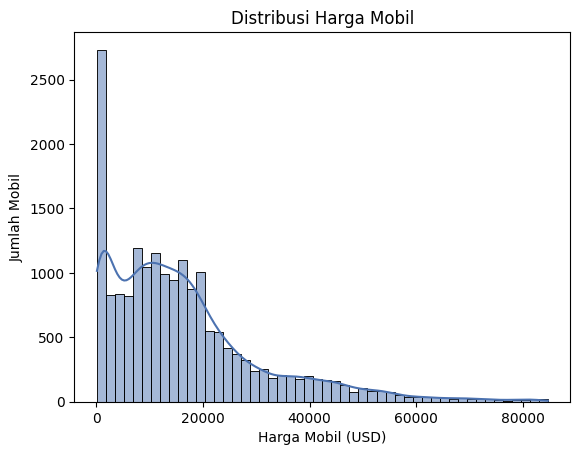

In [19]:
sns.histplot(data=data, x="Price", bins=50, kde=True, color="#4C72B0")
plt.xlabel("Harga Mobil (USD)")
plt.ylabel("Jumlah Mobil")
plt.title("Distribusi Harga Mobil")
plt.show()

Interpretasi:
- Distribusi miring ke kanan
- Banyak mobil murah dan sedikit yang mahal
- menggambarkan pola umum pasar mobil bekas

### b) Umur Mobil vs Harga

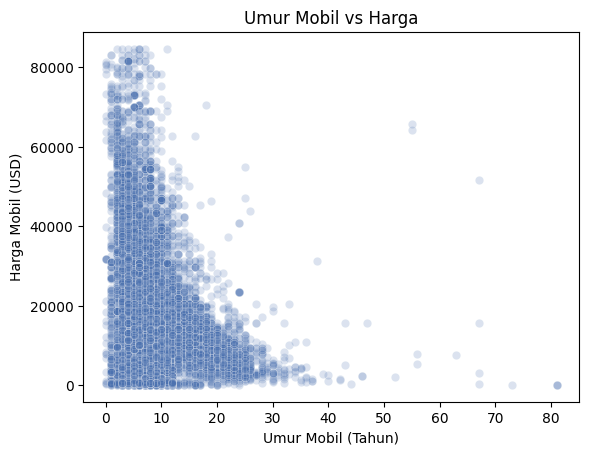

In [21]:
sns.scatterplot(data=data, x="Age", y="Price", color="#4C72B0", alpha=0.2)
plt.xlabel("Umur Mobil (Tahun)")
plt.ylabel("Harga Mobil (USD)")
plt.title("Umur Mobil vs Harga")
plt.show()

Interpretasi:
- Tren Menurun
- Semakin tua mobil, harganya semakin murah
- Hubungan ini tidak sepenuhnya linear ( Depresiasi melambat pada mobil yang sangat tua atau antik )
- Coba modeling menggunakan Model berbasis Pohon

### c) Harga rata rata per tipe bahan bakar

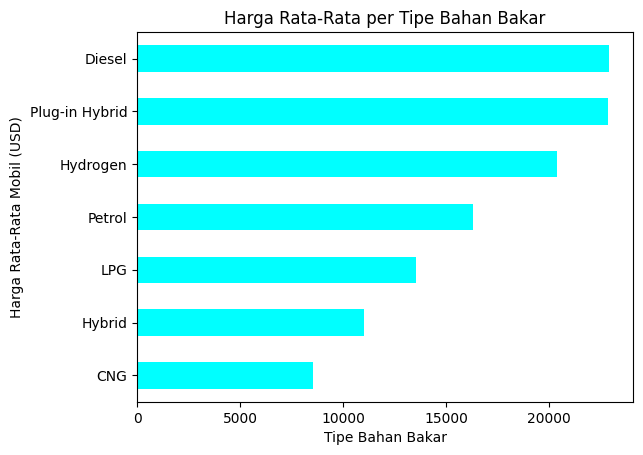

In [28]:
data.groupby("Fuel type")["Price"].mean().sort_values().plot(kind="barh", color="cyan")
plt.xlabel("Tipe Bahan Bakar")
plt.ylabel("Harga Rata-Rata Mobil (USD)")
plt.title("Harga Rata-Rata per Tipe Bahan Bakar")
plt.show()

Interpretasi:
- Mobil bekas dengan Bahan Bakar (Diesel, Plug-in Hybrid dan Hydrogen) Cenderung memiliki harga jual kembali tinggi
-  Sinyal bahwa `Fuel type` berguna untuk Prediction

## Preprocessing - Encoding & Split

Pilih fitur kategori penting (jumlah kategori wajar) lalu one-hot encode.

In [29]:
fit_num = ["Levy", "Engine volume", "Mileage", "Cylinders", "Airbags", "Turbo", "Age"]
fit_cat = ["Manufacturer", "Category", "Leather interior","Fuel type", "Gear box type", "Drive wheels", "Wheel"]

In [30]:
X = pd.get_dummies(data[fit_cat + fit_num],
                   columns=fit_cat,
                   drop_first=True)
y = data["Price"]
print(X.shape, y.shape)

(18694, 92) (18694,)


In [31]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(14955, 92) (3739, 92) (14955,) (3739,)


Interpretasi:
- OHE mengubah Kategori menjadi kolom 1 dan 0
- Random Forest tidak membutuhkan fitur scaling
- lanjutkan langsung ke pemodelan

## Modeling - Decission Tree vs Random Forest

- **Decision Tree**: satu pohon keputusan, cepat tapi rawan overfit.
- **Random Forest**: rata-rata banyak pohon (di sini 100), jauh lebih stabil & akurat.

In [32]:
dt = DecisionTreeRegressor(random_state=42,
                           max_depth=12)

dt.fit(X_train, y_train)
yp_dt = dt.predict(X_test)

print("MAE:", mean_absolute_error(y_test, yp_dt))
print("R2:", r2_score(y_test, yp_dt))

MAE: 5019.579433122549
R2: 0.6734081566919163


In [33]:
rf = RandomForestRegressor(random_state=42,
                           n_estimators=100,
                           max_depth=12)

rf.fit(X_train, y_train)
yp_rf = rf.predict(X_test)

print("MAE:", mean_absolute_error(y_test, yp_rf))
print("R2:", r2_score(y_test, yp_rf))

MAE: 4460.8242947257595
R2: 0.7672420370300979


## Evaluasi

In [43]:
def skor(y_true, y_pred):
  return{
      "MAE": mean_absolute_error(y_true, y_pred),
      "R2": r2_score(y_true, y_pred),
      "RMSE": mean_squared_error(y_true, y_pred) ** 0.5
  }


result = pd.DataFrame({
    "Decision Tree": skor(y_test, yp_dt),
    "Random Forest": skor(y_test, yp_rf)
}).T.round(3)

result.columns = ["MAE", "R2", "RMSE"]
result

,MAE,R2,RMSE
Decision Tree,5019.579,0.673,8513.445
Random Forest,4460.824,0.767,7187.121


Interpretasi

  1. Perbandingan Performa Model
  
  - Random Forest:
    - $R^2 = 0.767$ (Artinya, model ini mampu menjelaskan 76.7% variasi dari harga Mobil).
    - MAE = 4.460 & MSE = 5.165e+07 (Angka error-nya lebih rendah).
  
  - Decision Tree:
    - $R^2 = 0.673$ (Hanya mampu menjelaskan 67.3% variasi).
    - MAE = 5.019 & MSE = 7.247e+07 (Angka error-nya lebih tinggi).
  
  2. Mengapa Random Forest Jauh Lebih Baik?
      - Konsep Kerja (Ensemble): Decision Tree tunggal sangat mudah overfitting (terlalu menghafal data latihan sehingga mudah meleset saat melihat data baru). Sebaliknya, Random Forest menggabungkan ratusan pohon keputusan (trees) dan mengambil rata-rata keputusannya.
      - Kestabilan: Karena menggabungkan banyak pohon, hasil prediksi Random Forest jauh lebih stabil, tahan terhadap outlier, dan tidak mudah goyah ketika menemui pola data yang rumit.

  💡 Kesimpulan Belajar
  
  Dalam machine learning, satu pohon keputusan (Decision Tree) seringkali kurang optimal atau mudah overfit. Dengan menggunakan Random Forest (gabungan banyak pohon), performa prediksi meningkat secara signifikan, dibuktikan dengan naiknya nilai $R^2$ dan turunnya nilai error secara drastis!

### a) Grafik Perbandingan Grafik

Text(0.5, 1.0, 'R2 (Semakin besar semakin baik)')

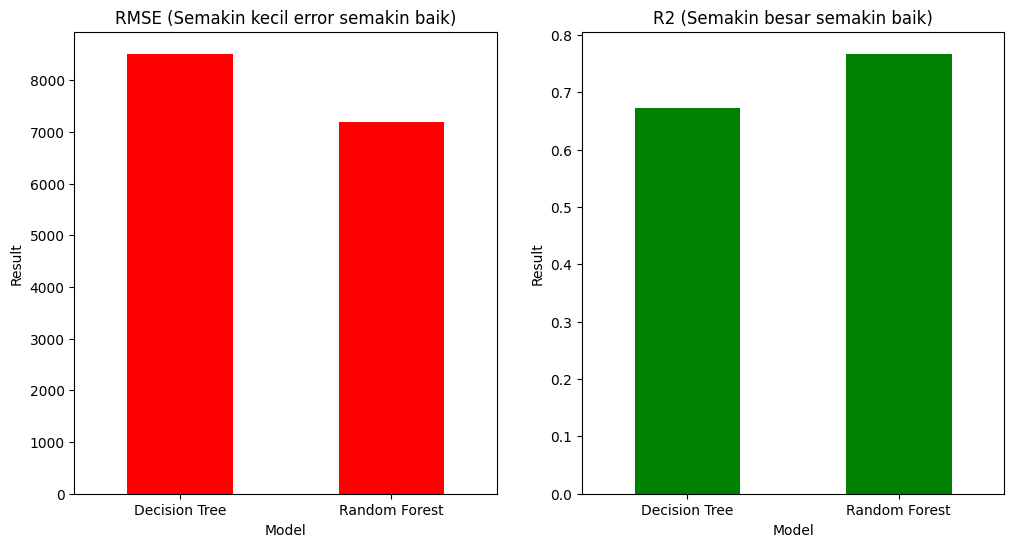

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

result["RMSE"].plot(kind="bar", ax=axes[0], color="red")
axes[0].set_xlabel("Model")
axes[0].tick_params(axis='x', rotation=0)
axes[0].set_ylabel("Result")
axes[0].set_title("RMSE (Semakin kecil error semakin baik)")

result["R2"].plot(kind="bar", ax=axes[1], color=["green"])
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Result")
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_title("R2 (Semakin besar semakin baik)")

Interpretasi:
-  Random Forest unggul di kedua metriks

### b) Feature Importance

In [51]:
imp_feat = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top_10 = imp_feat.head(10)

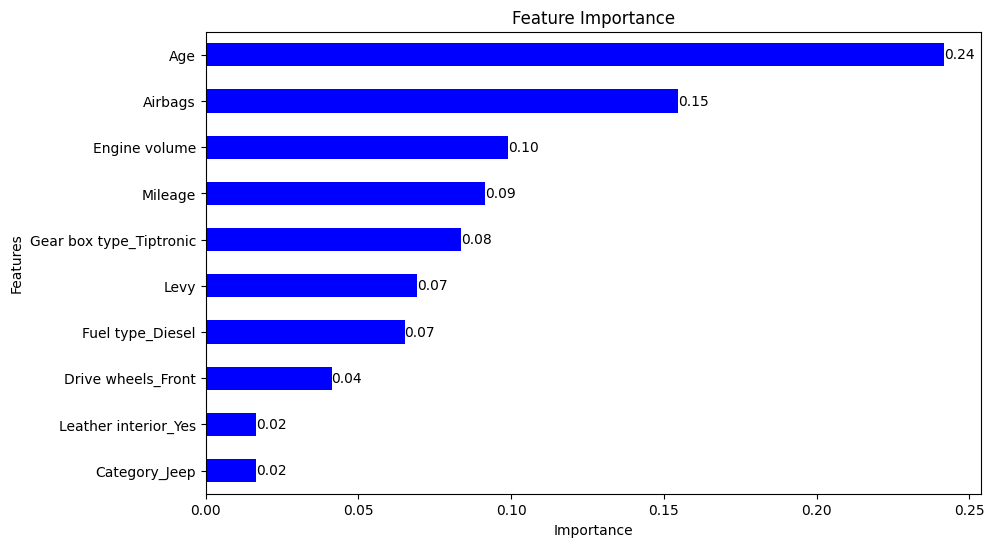

In [61]:
plt.figure(figsize=(10, 6))
top_10.sort_values().plot(kind="barh", color="blue")
for i, v in enumerate(top_10.sort_values()):
  plt.text(v, i, f"{v:.2f}", color="black", va="center")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance")
plt.show()

Interpretasi:
-  Fitur seperti `Age`, `Mileage`, `Engine volume`, dan `Levy` biasanya mendominasi — masuk akal karena umur, jarak tempuh, dan kapasitas
mesin adalah penentu utama harga mobil bekas.


**Insight:**
- dealer bisa fokus pada faktor ini saat menaksir harga, dan model bisa dipakai sebagai penaksir otomatis.

### c) Prediciton vs Actual Price ( Random Forest )

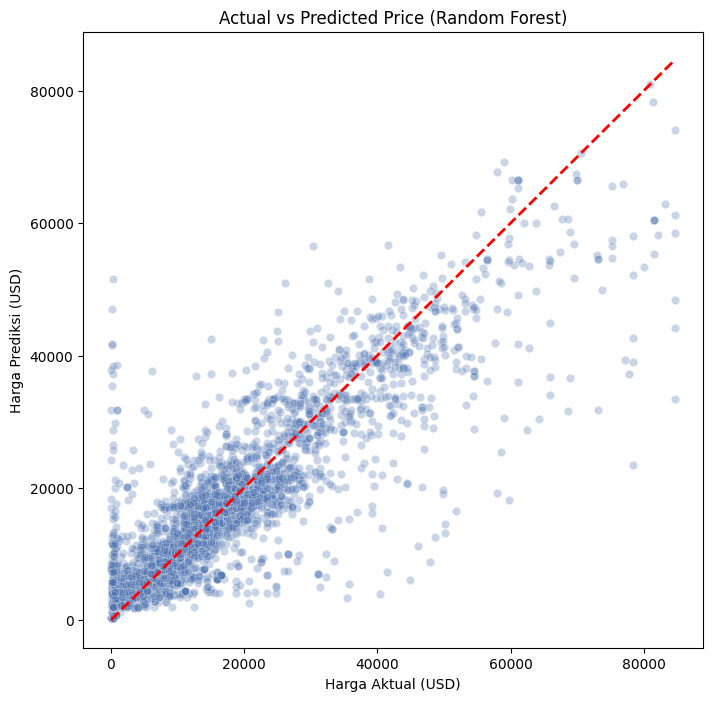

In [62]:
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=yp_rf, alpha=0.3, color="#4C72B0")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Harga Aktual (USD)")
plt.ylabel("Harga Prediksi (USD)")
plt.title("Actual vs Predicted Price (Random Forest)")
plt.show()

Interpretasi:
-  Sebagian besar titik dekat garis merah.
- Penyimpangan lebih besar pada mobil mahal (data lebih sedikit di rentang itu), pola umum pada prediksi harga.

## Kesimpulan and Insight

 Data mentah perlu **dibersihkan** dulu (Levy, Mileage, Engine volume, umur) — langkah krusial yang sering menentukan keberhasilan model.
- **Random Forest mengalahkan Decision Tunggal** karena meredam overfitting lewat rata-rata banyak pohon.
- **`feature_importances_`** menunjukkan `Age`, `Mileage`, dan `kapasitas mesin` sebagai   penentu harga utama — sejalan dengan intuisi pasar mobil bekas.
- **Insight bisnis:** model ini layak jadi *price estimator* awal bagi dealer untuk   menaksir harga jual/beli secara objektif.